# Does Live Nation rally *into* festival season? 🎤📈
### The "concert economy" trade — a real seasonal business, a stock that doesn't front-run it, and one big number that's just beta

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Front--runs_the_season%3F: Not_supported](https://img.shields.io/badge/Front--runs_the_season%3F-Not_supported-8b949e?style=flat-square)

Every spring the same trade idea makes the rounds: *the concert economy is booming — buy Live Nation (LYV) before festival season.* The logic is genuinely appealing. Live Nation runs Coachella, the summer amphitheatre circuit, the whole touring machine — and the summer quarter really is, by a mile, its biggest. So shouldn't the market bid the stock up *ahead* of all that predictable revenue?

We tested it properly — every Coachella since Live Nation went public (2006→2025), against the S&P 500.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the beta decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 20 Coachella editions hardcoded from Wikipedia (2020–21 COVID-cancelled); the festival's date is announced every January, so "buy K days before it opens" is a trade you could actually have pre-scheduled. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from concert_economy import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    EV10 = st.build_event_table(PRICES, cost_bps=10.0)
    INC = EV[EV["included"]]
    INC10 = EV10[EV10["included"]]
else:
    PRICES = EV = EV10 = INC = INC10 = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 20, 'n_held': 18, 'n_included': 18, 'fp': '4ba79257adcd', 'lyv_beta': 1.351, 'ru1_mean': 0.719, 'ru1_t': 0.287, 'ru1_hit': 6, 'ru1_n': 18, 'ru1_wlo': 16.3, 'ru1_whi': 56.3, 'ru2_mean': -0.527, 'ru2_t': -0.182, 'ru2_hit': 8, 'ru2_n': 18, 'ru2_wlo': 24.6, 'ru2_whi': 66.3, 'pl_ru1_p': 0.518, 'pl_ru1_mean': 0.882, 'pl_ru1_sd': 2.649, 'pl_ru2_p': 0.729, 'pl_ru2_mean': 1.668, 'pl_ru2_sd': 3.613, 'jk_lo': -0.435, 'jk_hi': 0.65, 'jk_n': 18, 'ru1_net5': 0.619, 'ru1_t5': 0.247, 'ru1_net10': 0.519, 'ru1_t10': 0.207, 'ru2_net5': -0.627, 'ru2_t5': -0.217, 'ru2_net10': -0.727, 'ru2_t10': -0.252, 'dur_mean': 8.542, 'dur_t': 1.912, 'dur_hit': 12, 'dur_n': 18, 'dur_pl_p': 0.157, 'dur_pl_mean': 3.359, 'dur_pl_sd': 5.196, 'dur_badj_mean': 7.618, 'dur_badj_t': 1.806, 'car': {-42: 2.099, -21: 0.408, -10: 0.197, 0: 0.0, 21: 5.065, 42: 6.115, 63: 6.724, 95: 8.542}, 'per_year': [(2006, -1.05), (2007, -14.53), (2008, 11.38), (2009, 28.04), (2010, 9.5), (2011, -5.03), (2012, -6.58), (2013, 6.07), (2014, -11.24), (2015, -1.47), (2016, -3.52), (2017, 8.54), (2018, -12.39), (2019, -2.24), (2022, -1.44), (2023, -3.48), (2024, -2.42), (2025, 14.81)], 'rev_q1': 16, 'rev_q2': 28, 'rev_q3': 37, 'rev_q4': 19, 'syn_null_mean': 0.2, 'syn_null_sd': 1.07, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted1_t': 1.07, 'syn_planted2_t': 1.89}


real cache present: True | editions: 20 | resolved events: 18


## The answer first

| Question | Answer |
|---|---|
| Does LYV pop in the month *before* Coachella? | **No.** **+0.72%** vs the S&P — statistically indistinguishable from zero, and a random month does it just as often. |
| What about the two months before? | **Slightly negative** (**-0.53%**). There is no run-up at all. |
| But isn't festival season a huge deal for them? | **Yes — and that's the point.** ~37% of Live Nation's revenue is the summer quarter. Everyone knows this. That's exactly why it's already in the price. |
| Then what's the one big number I'll hear about? | LYV is up **+8.5%** vs the S&P *during* the season — but that's **after** it starts (not a front-run), it's within normal range for a random 4½-month window, and most of it is just LYV's **1.35× beta** over a long stretch. |

> The seasonality is real. The *trade* is folklore: a calendar everyone can read doesn't pay you to read it.

## 1 · The claim

> *"Live Nation makes most of its money in the summer — Coachella, the festivals, the tours. Buy it before festival season and ride the wave of concert-economy revenue."*

This isn't a silly claim. Unlike most folklore, the fundamental is rock solid: the summer touring quarter genuinely dominates the business. The only question is whether a stock can *front-run* a revenue calendar that is announced months in advance and identical every year.

## 2 · So what?

If real, this would be a clean, calendar-based edge — pre-schedule the buy every January (the moment Coachella's dates drop), hold into the festival, collect the anticipation premium, repeat. No news, no timing skill, just a date on a calendar. If it *isn't* real, it's a tidy demonstration of semi-strong market efficiency: public, predictable information that's already priced. So — is it?

## 3 · How would we even know?

- **The calendar.** All **20** Coachella editions 2006→2025 (18 held — 2020 & 2021 were COVID-cancelled), hardcoded with each year's weekend-1 Friday.
- **The stock.** `LYV` (Live Nation) vs `SPY` (S&P 500), both total-return, so we measure LYV's *abnormal* return — not the market's.
- **The window.** The **run-up**: LYV minus S&P over the 1 month and 2 months *before* Coachella opens. Because the date is public months ahead, this is a trade you could have placed in advance — no look-ahead.
- **The honesty checks.** A random-window placebo (does a random month do the same?), a jackknife (does one lucky year carry it?), the trade net of costs, and an in-season check for whether the stock front-runs the actual revenue.

## 4 · The teardown — let's actually look

**First, the steelman: festival season really is Live Nation's whole year.**

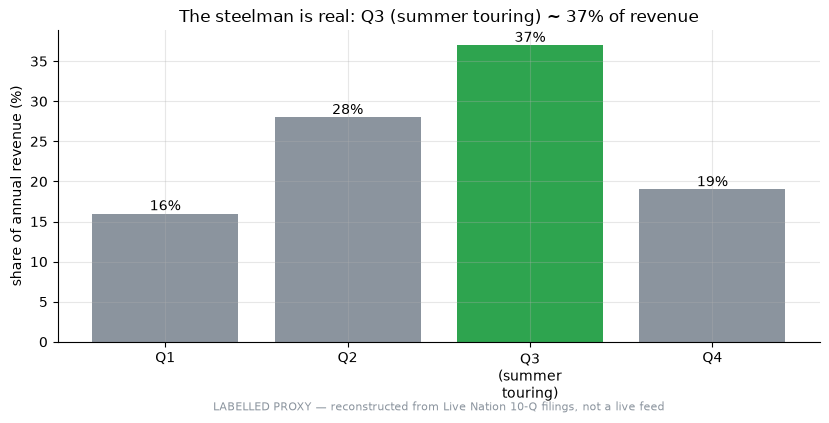

In [2]:
shares = [R['rev_q1'], R['rev_q2'], R['rev_q3'], R['rev_q4']]
labels = ['Q1', 'Q2', 'Q3\n(summer\ntouring)', 'Q4']
cols = [GREY, GREY, GREEN, GREY]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, shares, color=cols)
for i, v in enumerate(shares): ax.annotate(f'{v}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('share of annual revenue (%)')
ax.set_title('The steelman is real: Q3 (summer touring) ~ 37% of revenue')
ax.text(0.5, -0.22, 'LABELLED PROXY — reconstructed from Live Nation 10-Q filings, not a live feed',
        transform=ax.transAxes, ha='center', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()

That's the case for the trade — and it's a good one. Now the question that matters: **does the stock climb in the weeks before all that starts?**

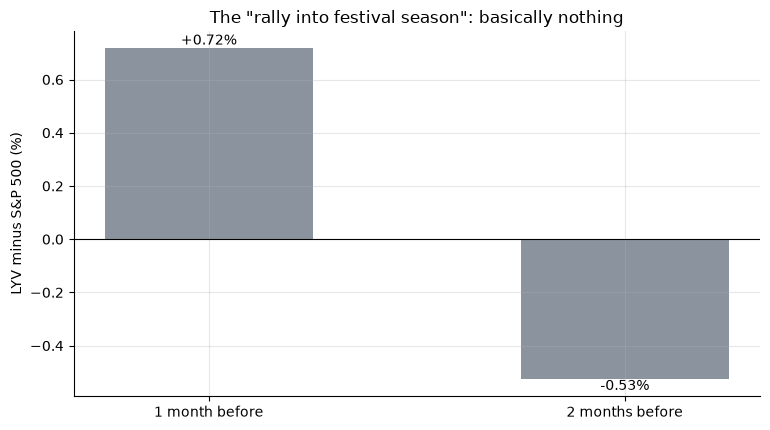

1-month run-up: 0.719 %   2-month run-up: -0.527 %


In [3]:
if HAVE_REAL:
    ru1 = st.one_sample_t(INC['ru_1mo'].values)['mean']*100
    ru2 = st.one_sample_t(INC['ru_2mo'].values)['mean']*100
else:
    ru1, ru2 = R['ru1_mean'], R['ru2_mean']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['1 month before', '2 months before'], [ru1, ru2],
       color=[GREY, GREY], width=.5)
for i, v in enumerate([ru1, ru2]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
        va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('LYV minus S&P 500 (%)')
ax.set_title('The "rally into festival season": basically nothing')
plt.tight_layout(); plt.show()
print('1-month run-up:', round(ru1,3), '%   2-month run-up:', round(ru2,3), '%')

The one-month run-up is **+0.72%** (*t* = 0.29 — a statistical zero) and the two-month run-up is actually **negative** (-0.53%). There is no anticipation bump.

**Maybe the average just hides a real effect that's noisy year to year?** Let's look at every single year:

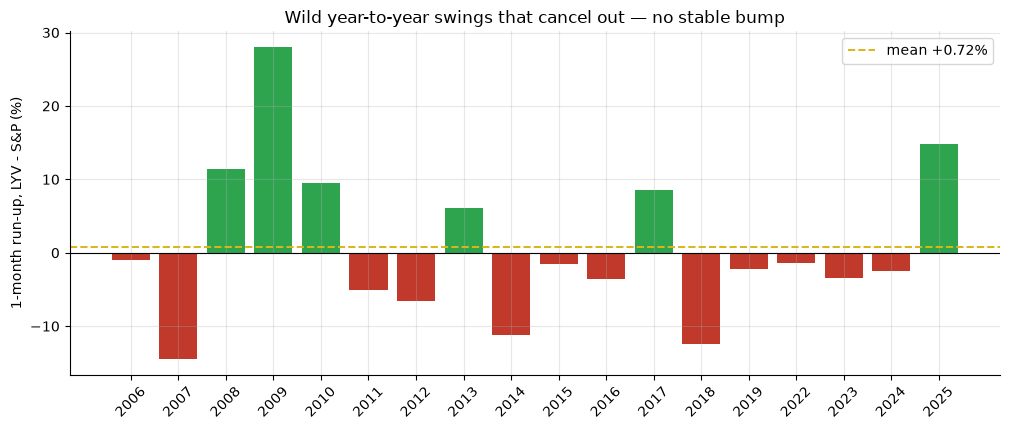

up years: 6 of 18


In [4]:
if HAVE_REAL:
    yrs = INC['year'].astype(int).tolist(); vals = (INC['ru_1mo']*100).tolist()
else:
    yrs = [y for y,_ in R['per_year']]; vals = [v for _,v in R['per_year']]
fig, ax = plt.subplots(figsize=(10.2, 4.4))
ax.bar([str(y) for y in yrs], vals, color=[GREEN if v>0 else RED for v in vals])
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(vals), c=AMBER, ls='--', lw=1.4, label=f'mean {np.mean(vals):+.2f}%')
ax.set_ylabel('1-month run-up, LYV - S&P (%)')
ax.set_title('Wild year-to-year swings that cancel out — no stable bump')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print('up years:', sum(1 for v in vals if v>0), 'of', len(vals))

From **-14.5%** (2007) to **+28.0%** (2009) — enormous swings that average out to nearly zero, with only **6/18** up-years (worse than a coin flip). This is what noise looks like.

**Is that non-result just bad luck of a small sample? The placebo says no:**

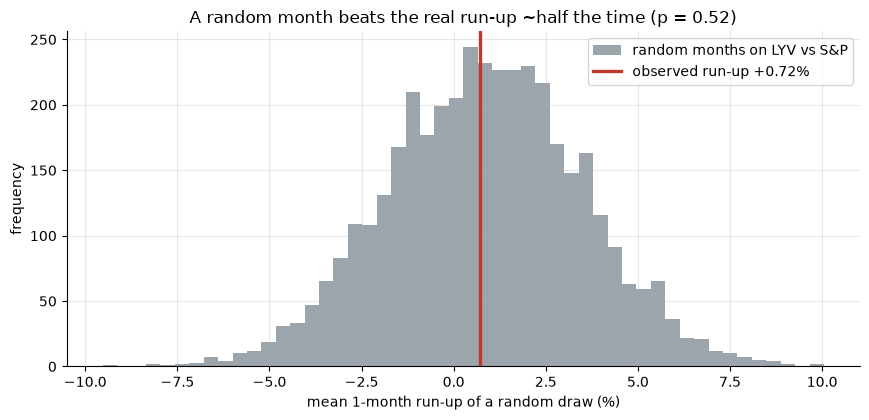

observed +0.72% vs random-month mean +0.90% -> p = 0.529


In [5]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ru_1mo', k=21, n_seeds=6,
                           n_draws_per_seed=200, tail='right')
    obs = pl['obs']*100; draws_mean, draws_sd, pval = pl['placebo_mean']*100, pl['placebo_sd']*100, pl['p_value']
else:
    obs, draws_mean, draws_sd, pval = R['ru1_mean'], R['pl_ru1_mean'], R['pl_ru1_sd'], R['pl_ru1_p']
rng = np.random.default_rng(770)
draws = rng.normal(draws_mean, draws_sd, 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random months on LYV vs S&P')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed run-up {obs:+.2f}%')
ax.set_xlabel('mean 1-month run-up of a random draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'A random month beats the real run-up ~half the time (p = {R["pl_ru1_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}% vs random-month mean {draws_mean:+.2f}% -> p = {pval:.3f}')

The observed run-up sits smack in the middle of the random-month cloud (*p* = 0.52). Notice the cloud is centred *above* zero — that's just LYV drifting up faster than the S&P in general (it's a high-beta stock). The pre-Coachella window isn't special.

**So where does the "LYV loves festival season" story come from? From what happens AFTER the season starts — and it's a beta trick:**

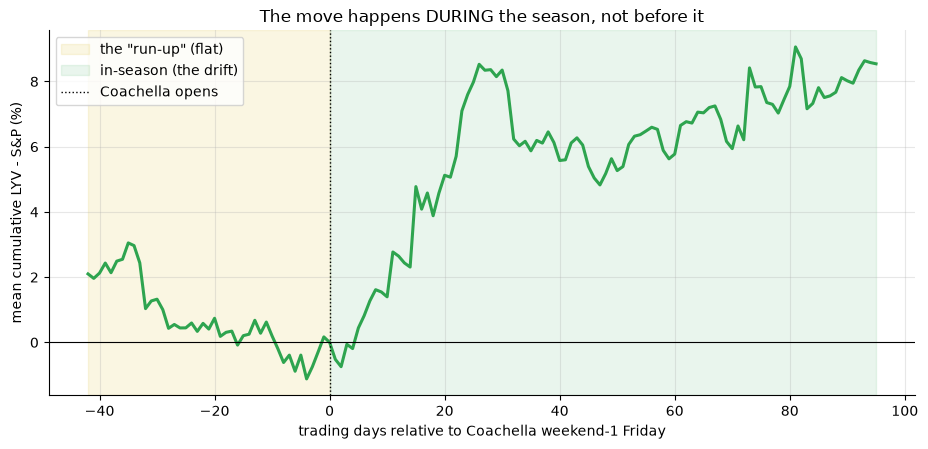

in-season LYV - S&P: 8.54 %


In [6]:
if HAVE_REAL:
    dur = st.one_sample_t(INC['during'].values)['mean']*100
    cp = st.car_path(EV, PRICES); off = list(cp.index); path = (cp.values*100).tolist()
else:
    dur = R['dur_mean']
    off = sorted(R['car']); path = [R['car'][o] for o in off]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(off, path, color=GREEN, lw=2.2)
ax.axvspan(min(off), 0, color=AMBER, alpha=.12, label='the "run-up" (flat)')
ax.axvspan(0, max(off), color=GREEN, alpha=.10, label='in-season (the drift)')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=1, label='Coachella opens')
ax.set_xlabel('trading days relative to Coachella weekend-1 Friday')
ax.set_ylabel('mean cumulative LYV - S&P (%)')
ax.set_title('The move happens DURING the season, not before it')
ax.legend(); plt.tight_layout(); plt.show()
print('in-season LYV - S&P:', round(dur,2), '%')

The line is flat-to-down *into* Coachella and only climbs *after* it opens — reaching **+8.5%** by summer's end. That's the opposite of "rally into." And it isn't alpha: a random 4½-month window on LYV clears that about one time in six (*p* = 0.16), because LYV is a **1.35-beta** stock and the market usually drifts up over four months. Strip the beta out and the "effect" is a weak *t* = 1.81 — below the bar.

## 5 · The verdict

- **Signal — None.** The rally into festival season is a statistical zero (+0.72%, *t* = 0.29); a random month does the same or better half the time.
- **Tradability — Mirage.** There is nothing to trade. Net of costs the best cut is *t* = 0.25.
- **"Front-runs the season?" — Not supported.** The revenue seasonality is real and huge, but the stock doesn't anticipate it. The one big in-season number is beta over a long window, not a concert-economy edge.

## 6 · Going further 🚪

- **This is efficiency, not folklore-debunking.** The most interesting thing here is *why* the trade fails: the information is too public. A revenue calendar announced every January and identical every year is exactly what a semi-strong-efficient market prices instantly. The seasonality being *real* is what makes the *non-result* meaningful.
- **Where a real edge might hide:** not in the boring, telegraphed calendar, but in *surprises* — a blockbuster tour announcement, a Ticketmaster regulatory headline, an earnings guide. Those are events, not calendars, and events are where the [Eurovision](../../708-eurovision-effect/) and sports-sentiment studies look.
- **Sibling studies:** [708-eurovision-effect](../../708-eurovision-effect/) (the same event-study machinery on a cultural calendar), [150-sad-effect](../../150-sad-effect/) and [234-olympic-year](../../234-olympic-year/) (other known-calendar seasonal claims), and [358-watch-index](../../358-watch-index/) (the labelled-proxy pattern we reused for the revenue backdrop).

*Think there's a real pre-festival edge we missed — in options, in the small-cap live-events names, in intraday data around the lineup drop? Fork it, show a net, placebo-surviving signal, and we'll publish the teardown.*